## Identify stable clusters

In [1]:
# eval "$(conda shell.bash hook)"
# conda init
# conda activate /work/islet_cartography_scrna/scrna_cartography_py_rapid
# python -m ipykernel install --user --name scrna_cartography_py_rapid --display-name "py_rapid"y_analysis --display-name "py_analysis"

In [2]:
# Path and system utilities
import os                    # Operating system interface
import sys                   # System-specific parameters and functions
from pyhere import here      # Reproducible project paths
from pathlib import Path # File system paths

# Single-cell data handling
import anndata as ad         # Core data structure for single-cell data
import rapids_singlecell as rsc
import scanpy as sc 

# Data visualization
import seaborn as sns        # Statistical data visualization
import matplotlib.pyplot as plt  # Plotting interface
import matplotlib            # Base matplotlib functionality
from matplotlib.backends.backend_pdf import PdfPages  # Save plots to multi-page PDFs

# Jaccard score
from sklearn.metrics import jaccard_score

# Dataframes
import pandas as pd
import numpy as np

Parameters

In [3]:
base_dir = str(here('data/annotate'))
plot_dir = os.path.join(base_dir, 'plot') 
objects_dir = os.path.join(base_dir, 'objects') 
files_dir = os.path.join(base_dir, 'files') 

anndata_dir = str(here('data/anndata/'))

# Seed
seed = 1000

Functions

In [4]:
def compute_jaccard(original_labels: pd.Categorical, bootstrap_labels: pd.Categorical) -> list:
    """
    Compute Jaccard index between original clustering and bootstrap clustering.

    Parameters
    ----------
    original_labels : pandas.Categorical
        Cluster labels from the original clustering (e.g., adata.obs['clusters']).
    bootstrap_labels : pandas.Categorical
        Cluster labels from the bootstrap clustering.

    Returns
    -------
    list
        Jaccard similarity scores for each original cluster.

    Notes
    -----
    For each cluster in the original labels:
        1. Create a binary mask of membership for that cluster.
        2. Compare it to every cluster in the bootstrap labels using Jaccard similarity.
        3. Keep the largest Jaccard score (i.e., the most similar bootstrap cluster).
        4. Append this best score to the results list.
    """

    # Get unique clusters from original dataset
    unique_clusters = np.unique(original_labels)
    scores = []

    # For each original cluster, calculate Jaccard score with all bootstrap clusters
    for cluster in unique_clusters:
        # Binary mask for the original cluster (1 = in cluster, 0 = not in cluster)
        orig_mask = (original_labels == cluster).astype(int)
        best_score = 0

        # Compare to all bootstrap clusters
        for b_cluster in np.unique(bootstrap_labels):
            # Binary mask for the bootstrap cluster
            boot_mask = (bootstrap_labels == b_cluster).astype(int)
            # Compute Jaccard similarity
            score = jaccard_score(orig_mask, boot_mask)
            # Keep the best (highest) score for this original cluster
            if score > best_score:
                best_score = score

        # Append best score for this cluster
        scores.append(best_score)

    return scores

Import data

In [5]:
# adata 
adata = ad.read_h5ad(os.path.join(anndata_dir, "AG_combined.h5ad"))

Stable clusters

In [6]:
seed = 1000

n_bootstrap = 500
resolutions = np.round(np.arange(0.05, 0.75, 0.05), 2)
min_cells = 10

# Optional: enable RAPIDS memory pooling for speed/stability
# from rmm import reinitialize
# reinitialize(pool_allocator=True)

stability_results = {}

for res in resolutions:
    print(f"Resolution: {res}")

    # Original clustering on GPU
    rsc.tl.leiden(
        adata,
        resolution=res,
        key_added=f"leiden_{res}",
        random_state=seed
    )

    original_labels = adata.obs[f"leiden_{res}"]

    jaccard_scores_bootstrap = []

    for boot in range(n_bootstrap):
        sample_size = int(adata.n_obs * 0.1)
        sample_idx = np.random.choice(adata.n_obs, sample_size, replace=False)
        adata_subset = adata[sample_idx, :].copy()

        # GPU neighbors + Leiden
        rsc.pp.neighbors(adata_subset, use_rep="X_latent_1")
        rsc.tl.leiden(
            adata_subset,
            resolution=res,
            key_added="bootstrap_clusters",
            random_state=None
        )

        # Align labels
        original_subset = original_labels.iloc[sample_idx].copy()
        boot_labels = adata_subset.obs["bootstrap_clusters"].copy()

        # Remove too-small clusters
        cluster_sizes = original_subset.value_counts()
        valid_clusters = cluster_sizes[cluster_sizes >= min_cells].index

        mask = np.isin(original_subset, valid_clusters)
        original_filt = original_subset[mask].values
        boot_filt = boot_labels[mask].values

        # Compute Jaccard
        if len(original_filt) > 0 and len(np.unique(original_filt)) > 4:
            scores = compute_jaccard(original_filt, boot_filt)
            jaccard_scores_bootstrap.extend(scores)

    stability_results[res] = jaccard_scores_bootstrap

# Build results DataFrame
results = (
    pd.DataFrame(
        [(res, s) for res, scores in stability_results.items() for s in scores],
        columns=["resolution", "jaccard"]
    )
)

# save results
# The leiden clusters
clustering = adata.obs.loc[:,adata.obs.columns.str.startswith('leiden_')].copy()
clustering.to_csv(os.path.join(files_dir, 'leiden_clusterings.csv'), index_label='barcode')

# The results
results.to_csv(os.path.join(files_dir, 'clustering_stability_results.csv'), index_label='cluster')

Resolution: 0.05
Resolution: 0.1
Resolution: 0.15
Resolution: 0.2
Resolution: 0.25
Resolution: 0.3
Resolution: 0.35
Resolution: 0.4
Resolution: 0.45
Resolution: 0.5
Resolution: 0.55
Resolution: 0.6
Resolution: 0.65
Resolution: 0.7


In [7]:
results = pd.read_csv(os.path.join(files_dir, 'clustering_stability_results.csv'), index_col=0)

In [8]:
def set_my_theme():
    sns.set_style("white")  # similar to theme_classic background

    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42

    plt.rcParams.update({
        # text + labels
        "axes.titlesize": 8,
        "axes.titleweight": "normal",
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 4,
        "legend.title_fontsize": 4,

        # line & tick colors
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "text.color": "black",

        # spine & tick thickness
        "axes.linewidth": 0.7,
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,

        # IMPORTANT: make ticks long & visible
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.bottom": True,
        "ytick.left": True,

        # background
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
    })

In [9]:
results['resolution'].unique()

array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
       0.6 , 0.65, 0.7 ])

2025-11-21 12:30:33 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-21 12:30:33 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-21 12:30:33 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-21 12:30:33 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


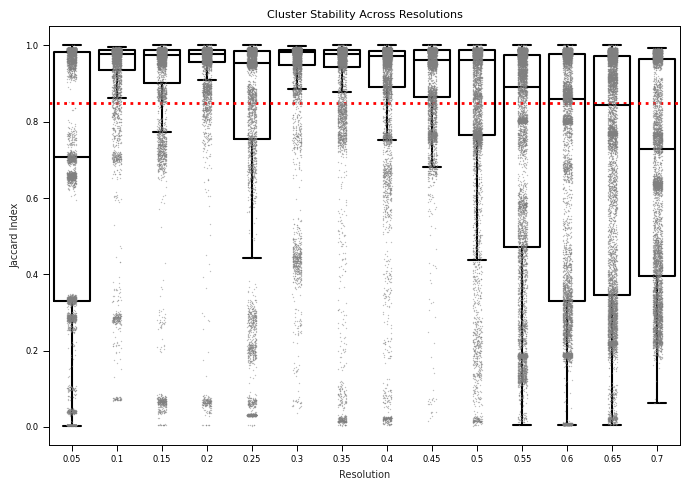

In [16]:
set_my_theme()
plt.figure(figsize=(7,5))

# Boxplot (hide outlier markers so points look cleaner)
sns.boxplot(
    x='resolution',
    y='jaccard',
    data=results,
    fliersize=0, 
    fill=False, 
    color="black"
)

# Overlay individual points
sns.stripplot(
    x='resolution',
    y='jaccard',
    data=results,
    alpha=0.5, size=1,
    jitter=True, 
    color="grey"
)

# Horizontal reference line
plt.axhline(y=0.85, linewidth=2, color='red', ls=':')

plt.xlabel('Resolution')
plt.ylabel('Jaccard Index')
plt.title('Cluster Stability Across Resolutions')
plt.tight_layout()
plt.show()

# so it seems all clusters are stable

In [11]:
stability_summary = results.groupby('resolution')['jaccard'].median()
best_resolution = stability_summary.idxmax()
max_median_jaccard = stability_summary.max()
stability_summary
print(f"The resolution with the highest median Jaccard is {best_resolution}, with a median of {max_median_jaccard:.4f}")
print(stability_summary)

The resolution with the highest median Jaccard is 0.3, with a median of 0.9819
resolution
0.05    0.707708
0.10    0.978507
0.15    0.973811
0.20    0.978133
0.25    0.953702
0.30    0.981914
0.35    0.978342
0.40    0.970951
0.45    0.960707
0.50    0.962146
0.55    0.891680
0.60    0.859104
0.65    0.843648
0.70    0.727477
Name: jaccard, dtype: float64
